In [2]:
import rdata
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle
import matplotlib.pyplot as plt

## Fixations

In [3]:
# Load MECO data with fixation and saccade objects
fixations_data = rdata.read_rda('../data/raw/joint_l2_fixation_trimmed_report_2.0.rda')['joint.fix.l2']
fixations_data = fixations_data[fixations_data['lang'] != 'en']
fixations_data = fixations_data[(fixations_data['dur'] > 80) | (fixations_data['dur'].isna())]

In [4]:
window_size = 2000
fixations_data['window_start'] = ((fixations_data['start'] - 1) // window_size) * window_size + 1
fixations_data['window_end'] = fixations_data['window_start'] + window_size - 1

In [5]:
fixations_df = (fixations_data.groupby(['subid', 'trialnum', 'window_start', 'window_end']).agg(
    fixation_duration=('dur', 'mean'),
    num_fixations=('dur', 'count'),
    frequency_of_regression=('word.reg.out', 'mean'),
    ).reset_index()).sort_values(['subid', 'trialnum', 'window_start'])

fixations_df['fixation_rate'] = fixations_df['num_fixations'] / window_size * 1000 * 60

# Then cumulative mean of per-window rates
for col in ['fixation_duration', 'frequency_of_regression', 'fixation_rate']:
    fixations_df[col] = (
        fixations_df.groupby(['subid', 'trialnum'])[col]
        .expanding()
        .mean()
        .reset_index(level=[0, 1], drop=True)
    )

fixations_df = fixations_df.groupby(['subid', 'trialnum']).apply(
lambda x: x.iloc[5:]
).reset_index(drop=True)

/var/folders/y2/4wrcf4_j2yggtw4qrwqkl7b00000gn/T/ipykernel_57218/3664743623.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fixations_df = fixations_df.groupby(['subid', 'trialnum']).apply(


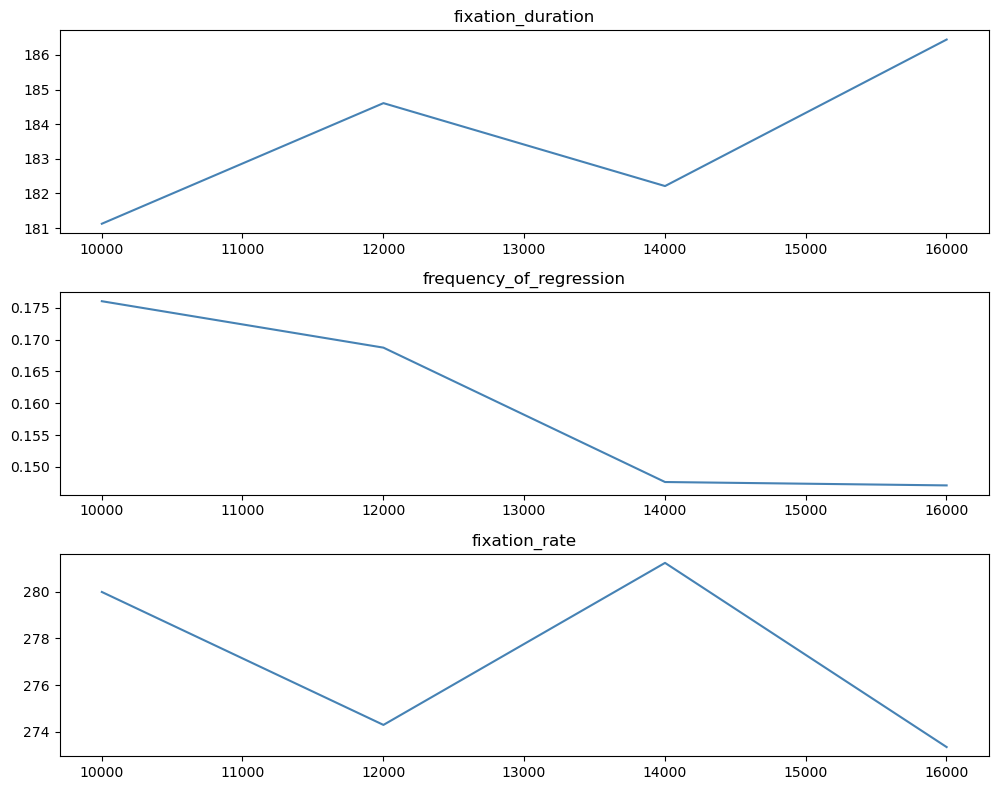

In [6]:
fixation_example = fixations_df[fixations_df['subid'] == 'DU_04']
fixation_example = fixation_example[fixation_example['trialnum'] == 2.0]

columns = ["fixation_duration", "frequency_of_regression", "fixation_rate"]

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

for ax, col in zip(axes.flat, columns):
    ax.plot(fixation_example["window_start"], fixation_example[col], color="steelblue")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [7]:
features = fixations_df[['fixation_duration', 'fixation_rate', 'frequency_of_regression']].fillna(0)

X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
# TODO: do we want to have more clusters? how to evaluate the quality?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features['cluster'] = kmeans.labels_
print(features.groupby('cluster').mean())

         fixation_duration  fixation_rate  frequency_of_regression
cluster                                                           
0               216.618984     239.668649                 0.143272
1               271.296390     200.239811                 0.145473


In [9]:
# with open('../data/models/kmeans_cognitive_load.pkl', 'wb') as f:
#     pickle.dump({'kmeans': kmeans, 'scaler': scaler}, f)

For n_clusters = 2 The average silhouette_score is : 0.3446794289918055
For n_clusters = 3 The average silhouette_score is : 0.3117883124248838
For n_clusters = 4 The average silhouette_score is : 0.30538500443184463


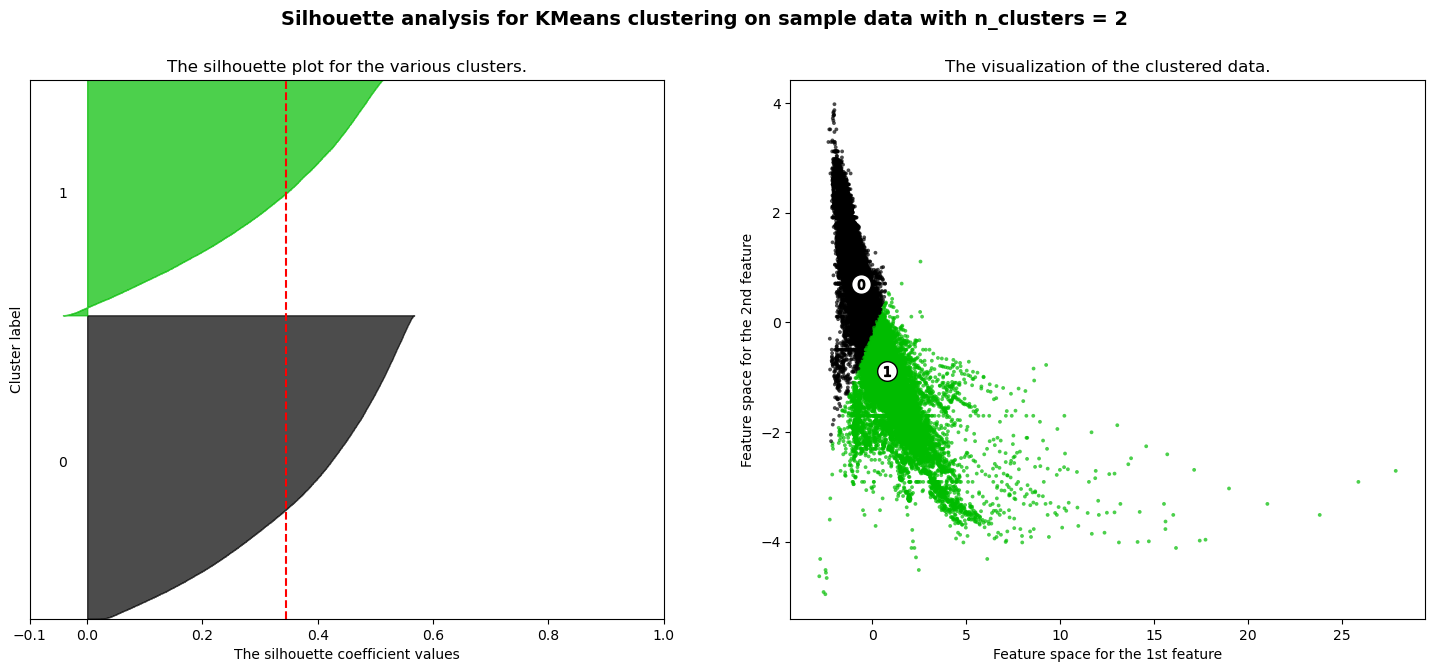

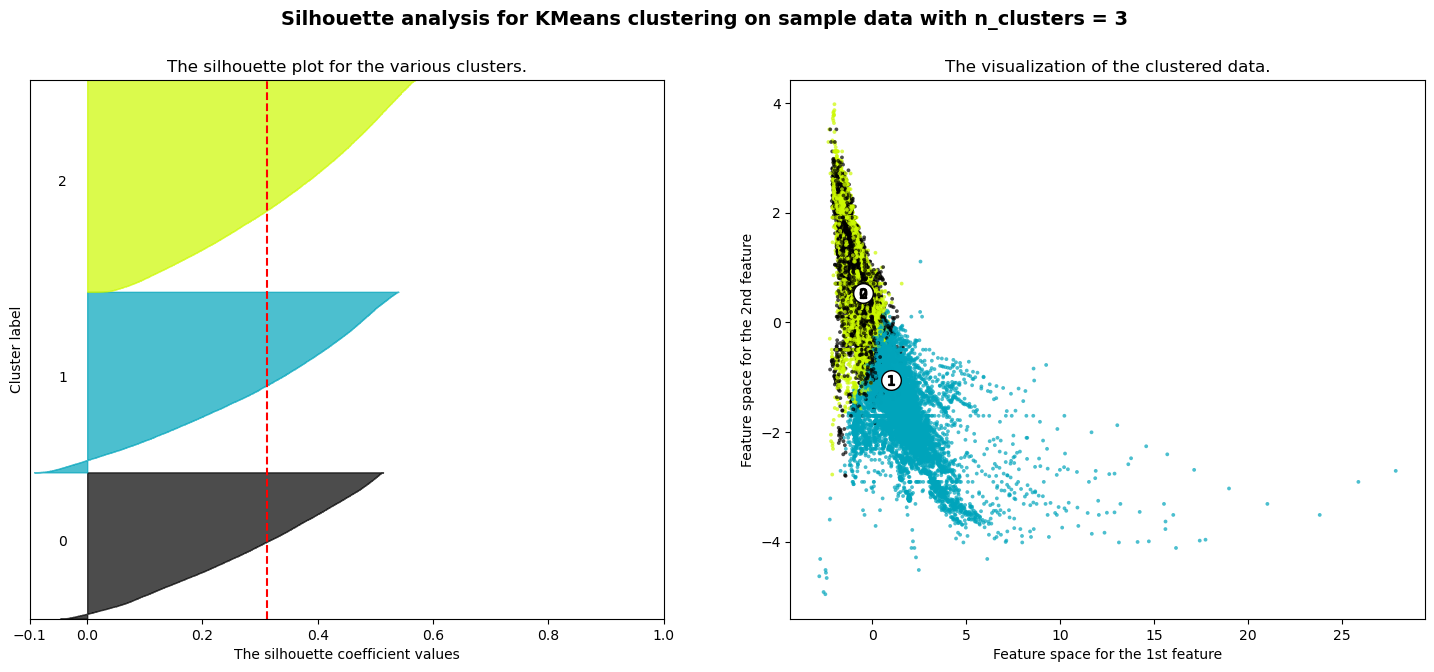

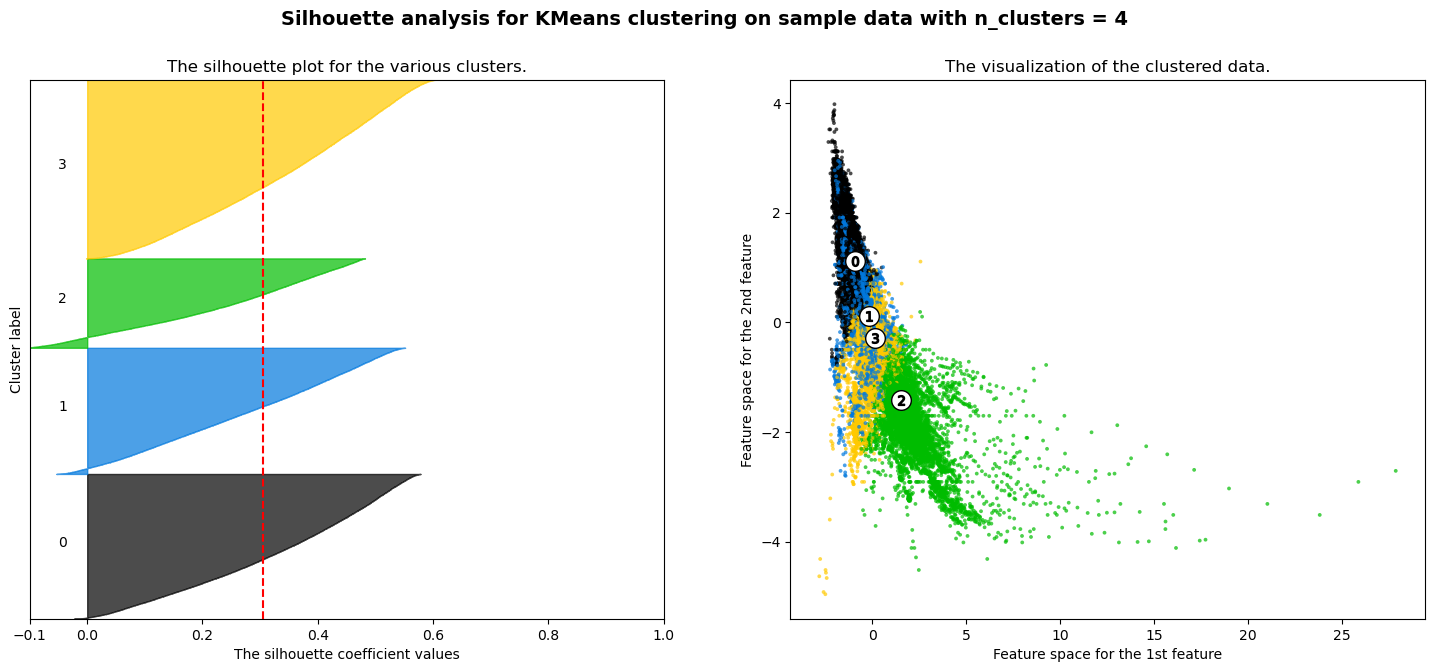

In [8]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
range_n_clusters = [2, 3, 4]
X = X_scaled
for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

## Saccades

In [ ]:
saccades_data = rdata.read_rda('../data/raw/joint_L2_sac_trimmed_wave1_2.0.rda')['joint.sac.l2']
saccades_data = saccades_data[saccades_data['lang'] != 'en']
saccades_data = saccades_data[saccades_data['msg'] == 'SAC']

In [172]:
saccades_data['window_start'] = ((saccades_data['start'] - 1) // window_size) * window_size + 1
saccades_data['window_end'] = saccades_data['window_start'] + window_size - 1

saccades_df = (saccades_data.groupby(['subid', 'trialnum', 'window_start', 'window_end']).agg(
    saccade_length=('dist.px', 'mean'),
    saccade_velocity=('pv.px', 'mean'),
    ).reset_index()).sort_values(['subid', 'trialnum', 'window_start'])

cumulative_cols = ['saccade_length', 'saccade_velocity']
saccades_df[cumulative_cols] = (
    saccades_df.groupby(['subid', 'trialnum'])[cumulative_cols]
    .expanding()
    .mean()
    .reset_index(level=[0, 1], drop=True)
)

# saccades_df['saccade_length_cum'] = (
#     saccades_df.groupby(['subid', 'trialnum'])['saccade_length']
#     .expanding()
#     .mean()
#     .reset_index(level=[0, 1], drop=True)
# )

# saccades_df['saccade_velocity_cum'] = (
#     saccades_df.groupby(['subid', 'trialnum'])['saccade_velocity']
#     .expanding()
#     .mean()
#     .reset_index(level=[0, 1], drop=True)
# )

saccades_df = saccades_df.groupby(['subid', 'trialnum']).apply(
    lambda x: x.iloc[3:]  # skip first 3 windows = first 6 seconds
).reset_index(drop=True)

/var/folders/y2/4wrcf4_j2yggtw4qrwqkl7b00000gn/T/ipykernel_73338/3280167686.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  saccades_df = saccades_df.groupby(['subid', 'trialnum']).apply(


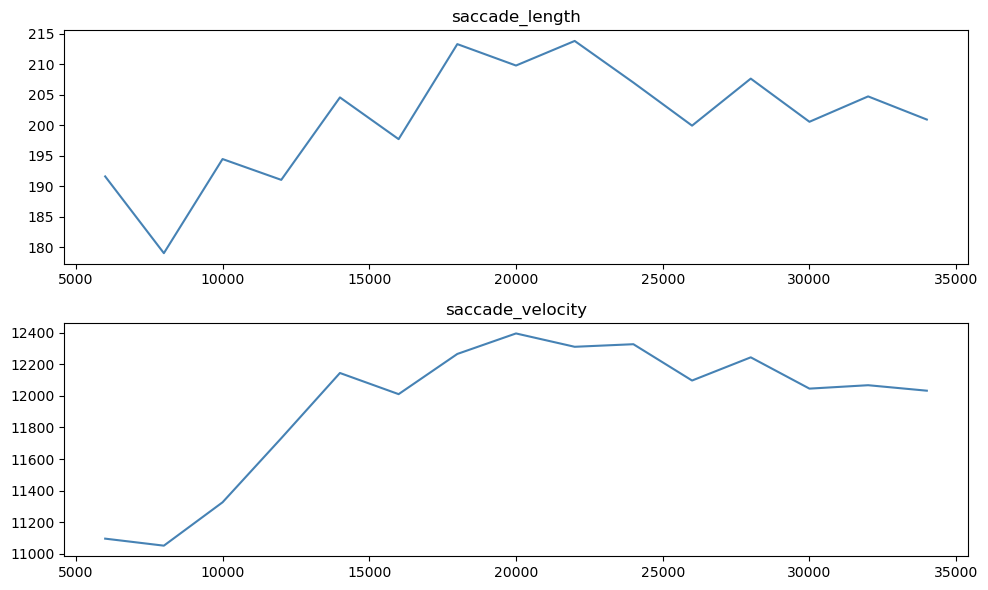

In [173]:
saccade_example = saccades_df[saccades_df['subid'] == 'DU_04']
saccade_example = saccade_example[saccade_example['trialnum'] == 1.0]

columns = ["saccade_length", "saccade_velocity"]

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for ax, col in zip(axes.flat, columns):
    ax.plot(saccade_example["window_start"], saccade_example[col], color="steelblue")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [174]:
features = saccades_df[['saccade_length', 'saccade_velocity']].fillna(0)

In [175]:
X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
# TODO: do we want to have more clusters? how to evaluate the quality?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features['cluster'] = kmeans.labels_
print(features.groupby('cluster').mean())

         saccade_length  saccade_velocity
cluster                                  
0            135.036608       8572.466044
1            191.476801      11636.558980


In [176]:
merged_df = pd.merge(fixations_df, saccades_df, on=['subid', 'trialnum', 'window_start', 'window_end'], how='inner')


In [177]:
features = merged_df[['fixation_duration', 'fixation_rate', 'frequency_of_regression']].fillna(0)
X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
# TODO: do we want to have more clusters? how to evaluate the quality?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features['cluster'] = kmeans.labels_
print(features.groupby('cluster').mean())

         fixation_duration  fixation_rate  frequency_of_regression
cluster                                                           
0               247.273265      12.555604                 0.149078
1               218.204629      37.697132                 0.134515


In [178]:
features = merged_df[['fixation_duration', 'fixation_rate', 'frequency_of_regression', 'saccade_velocity', 'saccade_length']].fillna(0)
X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
# TODO: do we want to have more clusters? how to evaluate the quality?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features['cluster'] = kmeans.labels_
print(features.groupby('cluster').mean())

         fixation_duration  fixation_rate  frequency_of_regression  \
cluster                                                              
0               250.957264      16.808318                 0.129781   
1               223.932179      22.424489                 0.166711   

         saccade_velocity  saccade_length  
cluster                                    
0             8622.148629      135.416356  
1            11416.090569      188.161902  


In [179]:
features = merged_df[['saccade_velocity', 'saccade_length']].fillna(0)
X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
# TODO: do we want to have more clusters? how to evaluate the quality?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features['cluster'] = kmeans.labels_
print(features.groupby('cluster').mean())

         saccade_velocity  saccade_length
cluster                                  
0             8578.117214      135.123135
1            11643.352989      191.632346


In [181]:
merged_df = merged_df.groupby(['subid', 'trialnum']).apply(
    lambda x: x.iloc[3:]  # skip first 3 windows = first 6 seconds
).reset_index(drop=True)

/var/folders/y2/4wrcf4_j2yggtw4qrwqkl7b00000gn/T/ipykernel_73338/3642209810.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_df = merged_df.groupby(['subid', 'trialnum']).apply(


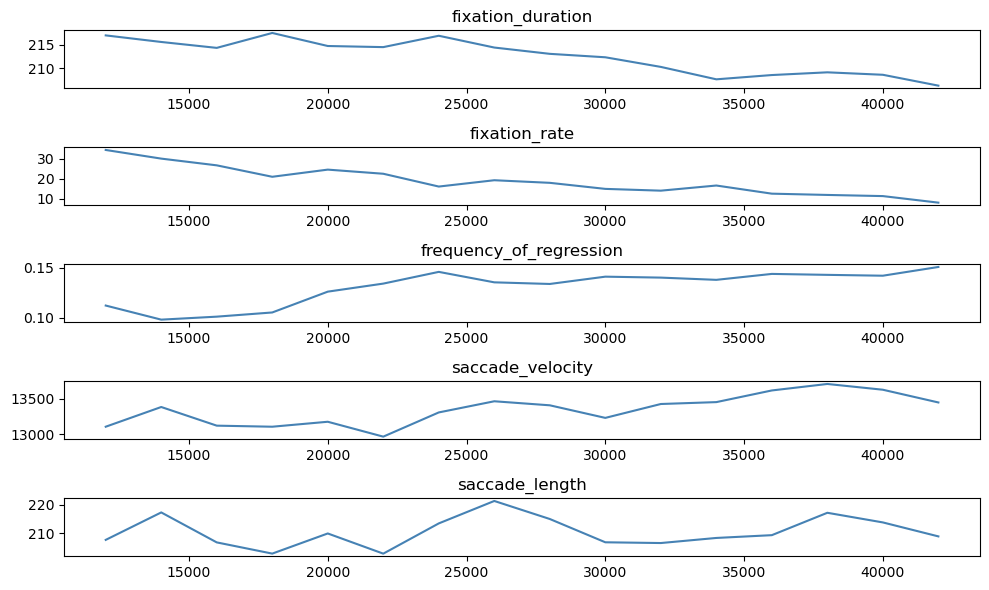

In [187]:
merged_example = merged_df[merged_df['subid'] == 'DU_04']
merged_example = merged_example[merged_example['trialnum'] == 4.0]

columns = ['fixation_duration', 'fixation_rate', 'frequency_of_regression', 'saccade_velocity', 'saccade_length']

fig, axes = plt.subplots(5, 1, figsize=(10, 6))

for ax, col in zip(axes.flat, columns):
    ax.plot(merged_example["window_start"], merged_example[col], color="steelblue")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [194]:
features = merged_df[['fixation_rate', 'frequency_of_regression', 'saccade_velocity', 'saccade_length']].dropna()
# features = merged_df[['fixation_duration', 'fixation_rate', 'frequency_of_regression', 'saccade_velocity', 'saccade_length']].fillna(0)
X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
# TODO: do we want to have more clusters? how to evaluate the quality?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features['cluster'] = kmeans.labels_
print(features.groupby('cluster').mean())

         fixation_rate  frequency_of_regression  saccade_velocity  \
cluster                                                             
0            16.698711                 0.172458      11515.101182   
1            13.822966                 0.129203       8676.431355   

         saccade_length  
cluster                  
0            191.022017  
1            137.175246  


## Blinks

In [91]:
fixations_data.iloc[150:180, 10:30]

,xn,yn,ym,dur,ps,sac.in,sac.out,type,blink,line,line.change,line.let,line.word,letternum,letter,wordnum,word,ianum,ia,sentnum
152,825.5,155.7,152.5,340.0,770.0,8,4,in,0.0,2.0,0.0,46.0,7.0,149,i,25.0,Their,25.0,Their,3.0
153,888.8,149.8,152.5,214.0,753.0,4,3,in,0.0,2.0,0.0,50.0,8.0,153,r,26.0,creation,26.0,creation,3.0
154,933.6,142.1,152.5,400.0,752.0,3,-9,in,0.0,2.0,0.0,53.0,8.0,156,t,26.0,creation,26.0,creation,3.0
155,798.2,162.7,152.5,92.0,761.0,-9,8,in,1.0,2.0,0.0,44.0,7.0,147,h,25.0,Their,25.0,Their,3.0
156,927.8,148.8,152.5,573.0,774.0,8,9,in,1.0,2.0,0.0,52.0,8.0,155,a,26.0,creation,26.0,creation,3.0
157,1070.2,139.5,152.5,289.0,743.0,9,5,in,0.0,2.0,0.0,61.0,10.0,164,,28.0,flatter,28.0,flatter,3.0
158,1150.4,141.6,152.5,152.0,741.0,5,10,in,0.0,2.0,0.0,66.0,10.0,169,t,28.0,flatter,28.0,flatter,3.0
159,1302.3,154.3,152.5,166.0,754.0,10,-4,in,0.0,2.0,0.0,76.0,12.0,179,r,30.0,more,30.0,more,3.0
160,1237.8,161.7,152.5,342.0,810.0,-4,-4,in,0.0,2.0,0.0,72.0,11.0,175,d,29.0,and,29.0,and,3.0
161,1175.0,159.0,152.5,273.0,817.0,-4,6,in,0.0,2.0,0.0,68.0,10.0,171,r,28.0,flatter,28.0,flatter,3.0


In [10]:
blink_data = rdata.read_rda('../data/raw/joint_L2_sac_trimmed_wave1_2.0.rda')['joint.sac.l2']
blink_data = blink_data[blink_data['lang'] != 'en']
blink_data = blink_data[blink_data['msg'] == 'BLINK']

In [48]:
blink_data['window_start'] = ((blink_data['start'] - 1) // window_size) * window_size + 1
blink_data['window_end'] = blink_data['window_start'] + window_size - 1

blinks_df = (blink_data.groupby(['subid', 'trialnum', 'window_start', 'window_end']).agg(
    num_blinks=('dur', 'count'),
    ).reset_index()).sort_values(['subid', 'trialnum', 'window_start'])

blinks_df['num_blinks_cum'] = (
    blinks_df.groupby(['subid', 'trialnum'])['num_blinks']
    .cumsum()
)
blinks_df['blink_rate'] = blinks_df['num_blinks_cum'] / blinks_df['window_end'] * 1000 * 60

In [52]:
blinks_df.iloc[1:20]

,subid,trialnum,window_start,window_end,num_blinks,num_blinks_cum,blink_rate
1,DU_04,3.0,2001.0,4000.0,1,1,15.000000
2,DU_04,3.0,4001.0,6000.0,1,2,20.000000
3,DU_04,4.0,16001.0,18000.0,1,1,3.333333
4,DU_04,4.0,30001.0,32000.0,1,2,3.750000
5,DU_04,6.0,1.0,2000.0,1,1,30.000000
6,DU_04,6.0,4001.0,6000.0,1,2,20.000000
7,DU_04,6.0,10001.0,12000.0,1,3,15.000000
8,DU_04,6.0,12001.0,14000.0,1,4,17.142857
9,DU_04,6.0,28001.0,30000.0,1,5,10.000000
10,DU_04,7.0,1.0,2000.0,1,1,30.000000


In [57]:
# Start from the full window timeline
blinks_df = pd.merge(
    fixations_df[['subid', 'trialnum', 'window_start', 'window_end']],
    blinks_df,
    on=['subid', 'trialnum', 'window_start', 'window_end'],
    how='left'
).fillna({'num_blinks': 0})

# Now cumsum and rate are computed over all windows including zero-blink ones
blinks_df['num_blinks_cum'] = (
    blinks_df.groupby(['subid', 'trialnum'])['num_blinks']
    .cumsum()
)
blinks_df['blink_rate'] = blinks_df['num_blinks_cum'] / blinks_df['window_end'] * 1000 * 60

In [74]:
sorted = blinks_df.sort_values(by=['subid', 'trialnum', 'window_start'])

In [78]:
sorted.iloc[10:40]

,subid,trialnum,window_start,window_end,num_blinks,num_blinks_cum,blink_rate
10,DU_04,1.0,30001.0,32000.0,0.0,0.0,0.000000
11,DU_04,1.0,32001.0,34000.0,0.0,0.0,0.000000
12,DU_04,1.0,34001.0,36000.0,1.0,1.0,1.666667
13,DU_04,2.0,10001.0,12000.0,0.0,0.0,0.000000
14,DU_04,2.0,12001.0,14000.0,0.0,0.0,0.000000
15,DU_04,2.0,14001.0,16000.0,0.0,0.0,0.000000
16,DU_04,2.0,16001.0,18000.0,0.0,0.0,0.000000
17,DU_04,3.0,10001.0,12000.0,0.0,0.0,0.000000
18,DU_04,3.0,12001.0,14000.0,0.0,0.0,0.000000
19,DU_04,3.0,14001.0,16000.0,0.0,0.0,0.000000


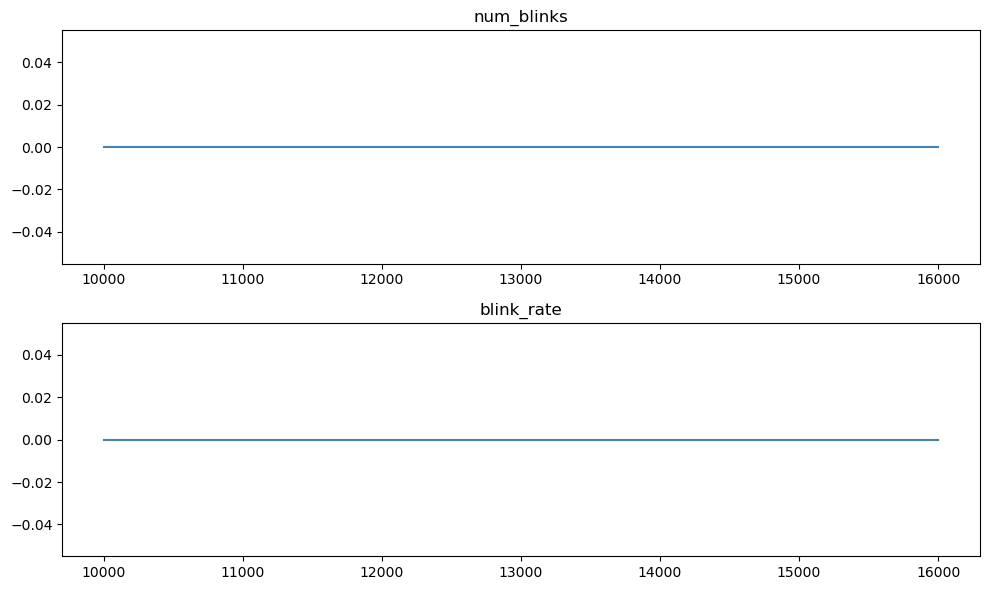

In [64]:
blink_example = blinks_df[blinks_df['subid'] == 'DU_04']
blink_example = blink_example[blink_example['trialnum'] == 2.0]

columns = ['num_blinks', 'blink_rate']

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

for ax, col in zip(axes.flat, columns):
    ax.plot(blink_example["window_start"], blink_example[col], color="steelblue")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [62]:
merged_df = pd.merge(fixations_df, blinks_df, on=['subid', 'trialnum', 'window_start', 'window_end'], how='inner')

In [63]:
features = merged_df[['fixation_duration', 'fixation_rate', 'frequency_of_regression', 'blink_rate']].fillna(0)
X = features.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train K Means model
# TODO: do we want to have more clusters? how to evaluate the quality?
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

features['cluster'] = kmeans.labels_
print(features.groupby('cluster').mean())

         fixation_duration  fixation_rate  frequency_of_regression  blink_rate
cluster                                                                       
0               221.633154      25.895821                 0.133904    4.477086
1               251.266112      10.392089                 0.150115   10.434830
